In [1]:
#Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#importing dependencies
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import scipy.io
from scipy.ndimage import gaussian_filter

In [3]:
#Loading dataset
DATA_PATH = "/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech"

print("Dataset root exists:", os.path.exists(DATA_PATH))
print("Folders:", os.listdir(DATA_PATH))

TRAIN_A = os.path.join(DATA_PATH, "part_A", "train_data", "images")
TEST_A  = os.path.join(DATA_PATH, "part_A", "test_data", "images")

TRAIN_B = os.path.join(DATA_PATH, "part_B", "train_data", "images")
TEST_B  = os.path.join(DATA_PATH, "part_B", "test_data", "images")

print("Train A images:", len(os.listdir(TRAIN_A)))
print("Test A images:", len(os.listdir(TEST_A)))


Dataset root exists: True
Folders: ['part_A', 'part_B']
Train A images: 300
Test A images: 182


In [4]:
def load_points(mat_path):

    mat = scipy.io.loadmat(mat_path)

    # ShanghaiTech annotation format
    points = mat["image_info"][0][0][0][0][0]

    return points

In [5]:
def generate_density_map(image, points, sigma=4):

    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for p in points:
        x = min(w-1, int(p[0]))
        y = min(h-1, int(p[1]))
        density[y, x] = 1
    density = gaussian_filter(density, sigma)
    return density


In [6]:
class ShanghaiTechDataset(Dataset):

    def __init__(self, image_folder, transform=None):

        self.image_paths = sorted(
            glob.glob(os.path.join(image_folder, "*.jpg"))
        )

        # Construct GT paths safely
        self.gt_paths = []

        for img_path in self.image_paths:

            filename = os.path.basename(img_path)        # IMG_42.jpg
            mat_name = "GT_" + filename.replace(".jpg",".mat")

            gt_folder = os.path.join(
                os.path.dirname(os.path.dirname(img_path)),
                "ground-truth"
            )

            gt_path = os.path.join(gt_folder, mat_name)

            self.gt_paths.append(gt_path)

        self.transform = transform


    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        gt_path  = self.gt_paths[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        points = load_points(gt_path)

        density = generate_density_map(img, points)

        if self.transform:
            img = self.transform(img)

        density = torch.tensor(density).unsqueeze(0)

        return img, density


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [8]:
dataset = ShanghaiTechDataset(TRAIN_A, transform=transform)

print("Total training images:", len(dataset))

loader = DataLoader(dataset, batch_size=1, shuffle=True)

Total training images: 300


In [9]:
for imgs, density in loader:

    print("Image shape:", imgs.shape)
    print("Density shape:", density.shape)
    print("Estimated Count:", density.sum(dim=[1,2,3]))

    break

Image shape: torch.Size([1, 3, 373, 561])
Density shape: torch.Size([1, 1, 373, 561])
Estimated Count: tensor([156.])


In [10]:
def density_label(density_patch):

    count = density_patch.sum().item()
    if count < 3:
        return 0      # empty
    elif count < 30:
        return 1      # low density
    else:
        return 2      # high density

In [9]:
class PatchDataset(torch.utils.data.Dataset):
    """
    Returns:
        patch_img: Tensor [3,H,W]
        density_patch: Tensor [1,H,W]
        router_label: 0/1/2
    """

    def __init__(self, base_dataset, patch_size=128, stride=64):
        self.samples = []

        for img, density in base_dataset:

            _, H, W = img.shape

            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    patch_img = img[:, y:y+patch_size, x:x+patch_size]
                    density_patch = density[:, y:y+patch_size, x:x+patch_size]

                    # Router label based on density sum
                    count = density_patch.sum().item()
                    if count < 3:
                        label = 0  # empty
                    elif count < 30:
                        label = 1  # low density
                    else:
                        label = 2  # high density

                    self.samples.append((patch_img, density_patch, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patch_img, density_patch, label = self.samples[idx]
        return patch_img, density_patch, torch.tensor(label)

In [10]:
patch_dataset = PatchDataset(dataset)
patch_loader = DataLoader(patch_dataset, batch_size=32, shuffle=True)

print("Total patch samples:", len(patch_dataset))

Total patch samples: 31565


In [13]:
from collections import Counter
labels = [label for _,_,label in patch_dataset.samples]
print(Counter(labels))

Counter({1: 15510, 0: 10648, 2: 5407})


In [16]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

device = "cuda" if torch.cuda.is_available() else "cpu"

class Router(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.model = resnet18(weights=None)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

router = Router().to(device)

In [17]:
import torch.nn.functional as F

# Compute class weights from your patch dataset counts
import torch
class_counts = torch.tensor([10648,15510,5407], dtype=torch.float, device=device)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

router_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(router.parameters(), lr=1e-4)

In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm

def train_router_save(loader, num_epochs=20, save_path="best_router.pth"):
    router.train()
    best_acc = 0.0
    scaler = torch.cuda.amp.GradScaler()  # for mixed precision

    for epoch in range(1, num_epochs+1):
        total_loss = 0
        correct = 0
        total = 0

        for imgs, _, labels in tqdm(loader):
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():  # mixed precision
                logits = router(imgs)
                loss = router_loss_fn(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * imgs.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += imgs.size(0)

        avg_loss = total_loss / total
        acc = correct / total * 100
        print(f"Epoch {epoch:02d}: Router Loss = {avg_loss:.4f}, Accuracy = {acc:.2f}%")

        # Save model if accuracy improved
        if acc > best_acc:
            best_acc = acc
            torch.save(router.state_dict(), save_path)
            print(f"Best router saved at epoch {epoch} with Acc = {best_acc:.2f}%")

In [19]:
train_router_save(patch_loader, num_epochs=10, save_path="best_router.pth")

/tmp/ipykernel_613/3888917377.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # for mixed precision
  0%|          | 0/987 [00:00<?, ?it/s]/tmp/ipykernel_613/3888917377.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # mixed precision
100%|██████████| 987/987 [00:34<00:00, 28.33it/s]


Epoch 01: Router Loss = 0.5434, Accuracy = 74.01%
Best router saved at epoch 1 with Acc = 74.01%


100%|██████████| 987/987 [00:25<00:00, 38.70it/s]


Epoch 02: Router Loss = 0.3641, Accuracy = 82.95%
Best router saved at epoch 2 with Acc = 82.95%


100%|██████████| 987/987 [00:26<00:00, 37.63it/s]


...

Epoch 08: Router Loss = 0.0648, Accuracy = 97.28%
Best router saved at epoch 8 with Acc = 97.28%


100%|██████████| 987/987 [00:26<00:00, 36.93it/s]


Epoch 09: Router Loss = 0.0553, Accuracy = 97.84%
Best router saved at epoch 9 with Acc = 97.84%


100%|██████████| 987/987 [00:34<00:00, 28.82it/s]

Epoch 10: Router Loss = 0.0537, Accuracy = 97.74%


In [20]:
import torch
from sklearn.metrics import confusion_matrix, classification_report

def eval_router(loader, verbose=True):
    router.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, _, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = router(imgs)
            pred = logits.argmax(dim=1)

            correct += (pred == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total * 100
    if verbose:
        print(f"Router Accuracy: {acc:.2f}%")
        print("Per-class counts:")
        from collections import Counter
        print("Labels:", Counter(all_labels))
        print("Predictions:", Counter(all_preds))
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, digits=4))
        print("\nConfusion Matrix:")
        print(confusion_matrix(all_labels, all_preds))

    return acc, all_labels, all_preds

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_patches(loader, num_images=1):
    router.eval()
    # We'll visualize the first `num_images` images in loader
    with torch.no_grad():
        for imgs, _, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            logits = router(imgs)
            preds = logits.argmax(dim=1)

            # Convert to CPU for visualization
            imgs_cpu = imgs.cpu().numpy()
            preds_cpu = preds.cpu().numpy()
            labels_cpu = labels.cpu().numpy()

            batch_size = imgs_cpu.shape[0]
            for i in range(min(batch_size, num_images)):
                img = imgs_cpu[i].transpose(1,2,0)  # C,H,W → H,W,C
                img = np.clip(img, 0, 1)

                plt.figure(figsize=(4,4))
                plt.imshow(img)
                plt.title(f"True: {labels_cpu[i]}, Pred: {preds_cpu[i]}")
                plt.axis('off')
                plt.show()

            num_images -= batch_size
            if num_images <= 0:
                break

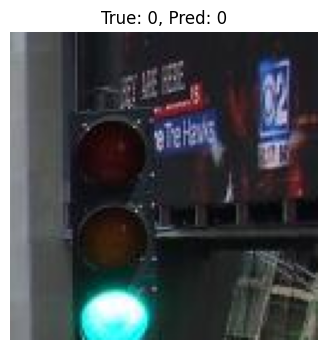

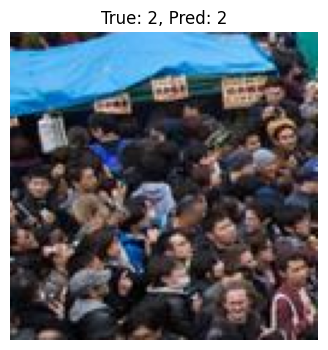

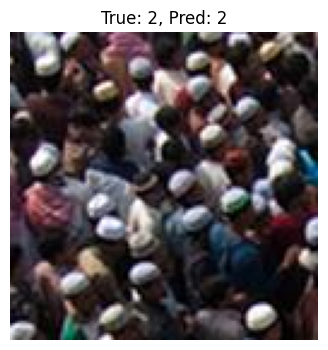

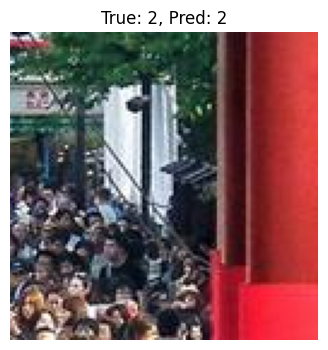

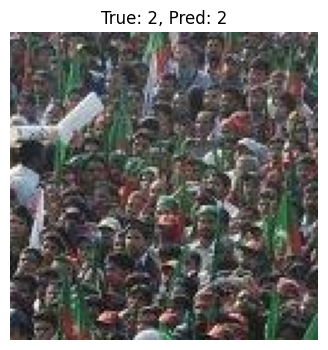

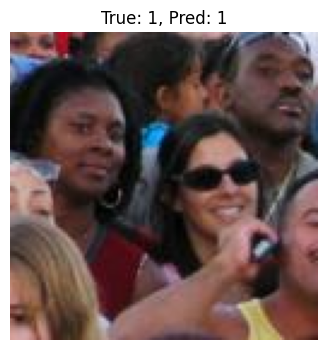

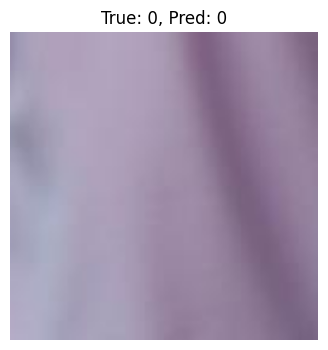

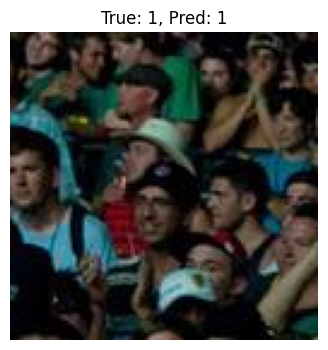

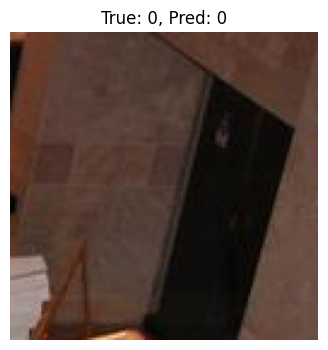

In [25]:
visualize_patches(patch_loader, num_images=9)

In [15]:
state_dict = torch.load("best_router.pth", map_location=device)

# If keys are prefixed with 'model.', remove it
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    if k.startswith("model."):
        new_key = k[6:]  # remove 'model.'
    else:
        new_key = k
    new_state_dict[new_key] = v

router.load_state_dict(new_state_dict)
router.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
print("Output shape:", outputs.shape)
print("GT shape:", gt_density.shape)

Output shape: torch.Size([1, 1, 128, 4096])
GT shape: torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import vit_b_16
from collections import OrderedDict
from torchvision.transforms import Resize

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# -------------------------
# Router
# -------------------------
router = models.resnet18(pretrained=False)
router.fc = nn.Linear(router.fc.in_features, 3)
router = router.to(device)
state_dict = torch.load("/content/best_router.pth", map_location=device)
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k[6:] if k.startswith("model.") else k
    new_state_dict[new_key] = v
router.load_state_dict(new_state_dict)
router.eval()
for p in router.parameters():
    p.requires_grad = False

# -------------------------
# CNN
# -------------------------
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.features(x)

cnn_model = SimpleCNN().to(device)
cnn_model.load_state_dict(torch.load("/content/best_cnn_epoch13.pth", map_location=device))
cnn_model.eval()

# -------------------------
# ViT
# -------------------------
class ViTDensity(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.vit = vit_b_16(weights='IMAGENET1K_V1' if pretrained else None)
        self.vit.heads = nn.Identity()
        self.density_head = nn.Conv2d(768, 1, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        x_resized = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        features = self.vit(x_resized)
        features = features.view(B, 768, 1, 1)
        features = F.interpolate(features, size=(H, W), mode='bilinear', align_corners=False)
        density = self.density_head(features)
        return density

vit_model = ViTDensity().to(device)
vit_model.load_state_dict(torch.load("/content/best_vit_epoch13.pth", map_location=device))
vit_model.eval()

# -------------------------
# Hybrid Model (Batched - Fixed)
# -------------------------
class HybridDensity(nn.Module):
    def __init__(self, cnn_model, vit_model, router_model):
        super().__init__()
        self.cnn = cnn_model
        self.vit = vit_model
        self.router = router_model

    def forward(self, patch_imgs):
        # patch_imgs: Tensor [B, C, H, W] — process entire batch at once
        imgs = patch_imgs.to(device)
        B, C, H, W = imgs.shape

        # Route entire batch
        with torch.no_grad():
            class_logits = self.router(imgs)
        confs = F.softmax(class_logits, dim=1)
        conf, cls = confs.max(dim=1)  # [B], [B]

        high_conf   = conf > 0.75
        cnn_mask    = high_conf & (cls == 1)   # low-density → CNN
        vit_mask    = high_conf & (cls == 2)   # high-density → ViT
        low_conf_mask = ~high_conf             # uncertain → CNN + ViT

        outputs = torch.zeros(B, 1, H, W, device=device)

        if cnn_mask.any():
            outputs[cnn_mask] = self.cnn(imgs[cnn_mask])

        if vit_mask.any():
            outputs[vit_mask] = self.vit(imgs[vit_mask])

        # empty class (cls==0, high conf) → stays zero (already initialised)

        if low_conf_mask.any():
            outputs[low_conf_mask] = (
                self.cnn(imgs[low_conf_mask]) + self.vit(imgs[low_conf_mask])
            )

        return outputs  # [B, 1, H, W]

hybrid_model = HybridDensity(cnn_model, vit_model, router).to(device)
hybrid_model.eval()

# -------------------------
# Compute MAE (Fixed)
# -------------------------
# PatchDataset returns (patch_img, density_patch, router_label)
# MAE is measured per-image (not summed over batch), then averaged

def compute_avg_mae(hybrid_model, patch_loader, device='cuda'):
    hybrid_model.eval()
    total_mae = 0.0
    n_samples  = 0

    with torch.no_grad():
        for batch in patch_loader:
            # Unpack correctly: index 1 is density, index 2 is router label
            if len(batch) == 2:
                patch_imgs, gt_density = batch          # no label
            elif len(batch) >= 3:
                patch_imgs, gt_density, _ = batch       # FIX: density=index1, label=index2
            else:
                raise ValueError(f"Unexpected batch length: {len(batch)}")

            patch_imgs = patch_imgs.to(device)
            gt_density = gt_density.to(device).float()  # [B, 1, H, W]

            outputs = hybrid_model(patch_imgs)           # [B, 1, H, W]

            # Per-image MAE: |predicted_count - gt_count| for each image in batch
            pred_counts = outputs.sum(dim=[1, 2, 3])     # [B]
            gt_counts   = gt_density.sum(dim=[1, 2, 3])  # [B]
            batch_mae   = torch.abs(pred_counts - gt_counts).sum().item()

            total_mae += batch_mae
            n_samples  += patch_imgs.size(0)

    avg_mae = total_mae / n_samples
    return avg_mae

avg_mae = compute_avg_mae(hybrid_model, patch_loader, device=device)
print(f"Average MAE across dataset: {avg_mae:.4f}")
